In [2]:
import strategies
import inspect
from typing import Any
import numpy as np
import matplotlib.pyplot as plt
from utils import (
    LETTER_TO_MOVE,
    Move,
    MoveHistory,
    get_counter,
    is_suffix,
    move_list_to_str,
    Strategy,
    resolve_moves,
    get_rated_substrings_v1,
    get_random_move,
)
import pandas as pd
import time
from run_tournament import simulate_game, simulate_tournament
from sortedcontainers import SortedList

In [3]:
def simulate_game_verbose(
    round_count: int, strategy_1: Strategy, strategy_2: Strategy
) -> tuple[tuple[int, float], tuple[int, float]]:
    strategy_1_history: MoveHistory = np.empty(round_count, dtype=object)
    strategy_1_score = 0
    strategy_1_time_ms: float = 0
    context_1: Any | None = None

    strategy_2_history: MoveHistory = np.empty(round_count, dtype=object)
    strategy_2_score = 0
    strategy_2_time_ms: float = 0
    context_2: Any | None = None

    score_1_per_round = np.empty(round_count, dtype=int)
    score_2_per_round = np.empty(round_count, dtype=int)

    for i in range(round_count):
        start_time = time.time()
        move_1, context_1 = strategy_1(
            strategy_1_history[:i], strategy_2_history[:i], context_1
        )
        strategy_1_time_ms += (time.time() - start_time) * 1000

        start_time = time.time()
        move_2, context_2 = strategy_2(
            strategy_2_history[:i], strategy_1_history[:i], context_2
        )
        strategy_2_time_ms += (time.time() - start_time) * 1000

        delta_1, delta_2 = resolve_moves(move_1, move_2)

        strategy_1_score += delta_1
        strategy_2_score += delta_2
        strategy_1_history[i] = move_1
        strategy_2_history[i] = move_2

        score_1_per_round[i] = strategy_1_score
        score_2_per_round[i] = strategy_2_score

    move_to_char = {0: "R", 1: "P", 2: "S"}
    history_1_str = "".join(move_to_char[m] for m in strategy_1_history)
    history_2_str = "".join(move_to_char[m] for m in strategy_2_history)
    print(f"Strategy 1: {history_1_str}")
    print(f"Strategy 2: {history_2_str}")

    rounds = np.arange(1, round_count + 1)
    _ = plt.plot(rounds, score_1_per_round, label="Strategy 1")
    _ = plt.plot(rounds, score_2_per_round, label="Strategy 2")
    _ = plt.xlabel("Round")
    _ = plt.ylabel("Cumulative score")
    _ = plt.legend()
    _ = plt.show()

    return (strategy_1_score, strategy_1_time_ms), (
        strategy_2_score,
        strategy_2_time_ms,
    )

In [4]:
class PatternBeater:
    def __init__(self, param: int) -> None:
        self.param: int = param

    def strat_temp_pattern_beater(
        self,
        my_moves: MoveHistory,
        opponent_moves: MoveHistory,
        context: tuple[list[Move], dict[tuple[Move, ...], dict[Move, int]]] | None,
    ) -> tuple[Move, tuple[list[Move], dict[tuple[Move, ...], dict[Move, int]]]]:
        """
        Plays the move that would counter what a pattern matcher would predict it
        would play. Result is that it confuses 1d pattern matchers into playing the
        the same move over and over again. Exploits this.

        Author: AugustusTheBirb
        """

        pattern_length: int = self.param

        if context is None:
            context = ([], {})

        my_list, patterns = context

        # update context
        if len(my_moves) > len(my_list):
            new_move: Move = my_moves[-1]
            if len(my_list) >= pattern_length:
                key = tuple(my_list[-pattern_length:])
                if key not in patterns:
                    patterns[key] = {Move.ROCK: 0, Move.PAPER: 0, Move.SCISSORS: 0}
                patterns[key][new_move] += 1
            my_list.append(new_move)

        if len(my_moves) > 10:
            if np.all(opponent_moves[-pattern_length:] == opponent_moves[-1]):
                return get_counter(opponent_moves[-1]), context

            key = tuple(my_list[-pattern_length:])
            d = patterns.get(key, {Move.ROCK: 0, Move.PAPER: 0, Move.SCISSORS: 0})

            arr = sorted(list(d.items()), key=lambda x: x[1])

            return get_counter(get_counter(arr[-1][0])), context
        else:
            return get_random_move(), context

In [5]:
# pyright: reportUnusedParameter=false
def strat_patternmatcher_1d_v1(
    my_moves: MoveHistory,
    opponent_moves: MoveHistory,
    context: tuple[int, dict[str, float], SortedList, str] | None,
) -> tuple[Move, tuple[int, dict[str, float], SortedList, str]]:
    """
    A more complex strategy, which tries to find a pattern in the
    opponets moves, to defeat the opponent, it is quite dependant
    on its parameters

    Author: lukassta
    """

    # ========PARAMETERS========
    MIN_SUBLIST_LENGTH = 1
    MAX_SUBLIST_LENGTH = 4
    BASE_SUBLIST_SCORE = 1
    LETTER_SCORE_MULT = 3
    # ==========================

    if context is None:
        context = (0, {}, SortedList(), "")

    iteration: int
    rated_substrings: dict[str, float]
    sorted_substrings: SortedList
    opponent_move_string: str
    iteration, rated_substrings, sorted_substrings, opponent_move_string = context

    opponent_move_string = move_list_to_str(list(opponent_moves))

    iteration, rated_substrings, sorted_substrings = get_rated_substrings_v1(
        opponent_move_string,
        min_lenght=MIN_SUBLIST_LENGTH,
        max_lenght=MAX_SUBLIST_LENGTH,
        base_score=BASE_SUBLIST_SCORE,
        letter_score_mult=LETTER_SCORE_MULT,
        context=(iteration, rated_substrings, sorted_substrings),
    )

    for _, substring in reversed(sorted_substrings):  # pyright: ignore[reportUnknownVariableType]
        if is_suffix(opponent_move_string, substring[:-1]):  # pyright: ignore[reportUnknownArgumentType]
            predicted_move: Move = LETTER_TO_MOVE[substring[-1]]
            counter_move: Move = get_counter(predicted_move)

            return counter_move, (
                iteration,
                rated_substrings,
                sorted_substrings,
                opponent_move_string,
            )

    return get_random_move(), context

<class 'pandas.Series'>
patternmatcher_2d_v1    -979.3
patternmatcher_1d_v1    -731.7
pattern_beater             7.3
beats_op_distribution      8.0
beats_last_meta1         -94.7
temp_pattern_beater        NaN
beats_last                 0.3
beats_modal              497.3
random                    -6.7
R2P2S6                   154.0
rock_or_paper            257.3
RPS_cyclic                 0.7
paper_only               991.7
scissors_only            989.0
rock_only                987.7
average_score            148.6
Name: temp_pattern_beater, dtype: float64
<class 'pandas.Series'>
patternmatcher_2d_v1    -208.0
patternmatcher_1d_v1      51.3
pattern_beater            36.0
beats_op_distribution     -9.0
temp_pattern_beater        NaN
beats_last_meta1        -163.0
beats_last              -320.0
beats_modal              529.0
random                     7.7
rock_or_paper            120.3
R2P2S6                    99.0
RPS_cyclic               -75.3
paper_only               988.0
scissors_on

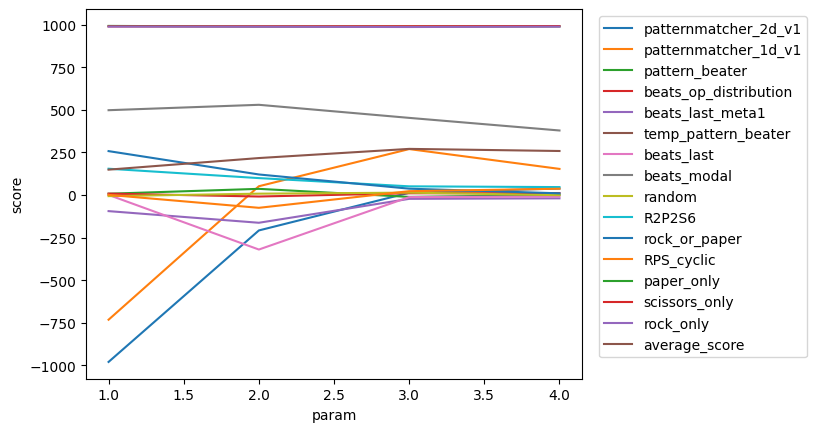

In [ ]:
# view hyperparam performace against all strategies

scores: list[pd.Series[int]] = []
strategy_dict: dict[str, Strategy] = {
    name: obj
    for name, obj in inspect.getmembers(strategies, inspect.isfunction)
    if name[:6] == "strat_"
}
strategies_list = list(strategy_dict.values())

for i in range(1, 5):
    test = PatternBeater(i)
    score_df, _ = simulate_tournament(
        3, 1000, set(strategies_list + [test.strat_temp_pattern_beater])
    )

    row = score_df.loc["temp_pattern_beater"]
    assert isinstance(row, pd.Series)
    scores.append(row)

results = pd.DataFrame(scores, index=range(1, 5))
results.index.name = "param"
ax = results.plot()
_ = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
_ = plt.ylabel("score")
plt.show()

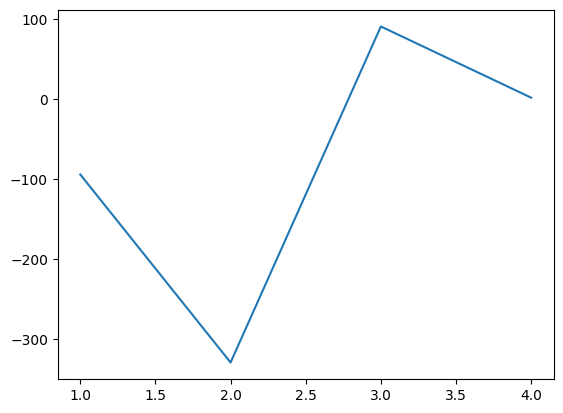

In [8]:
# view hyperparam performace against specific strat

scores: list[int] = []
for i in range(1, 5):
    test = PatternBeater(i)
    (score, _), _ = simulate_game(
        1000, test.strat_temp_pattern_beater, strategies.strat_beats_last_meta1
    )
    scores.append(score)
_ = plt.plot(range(1, 5), scores)

plt.show()

Strategy 1: RRPRRSSRPRRSPPPPSPPRPPPPRRPSPRPRSPRRPPRRPPRSRPSRPPSRRPRRRPRSRSPRRSPSPSSSSSSPPRSSSPRSSSPRSPSPPSRRRRRRRSRPPSSSPSRSRRRSRSSSRRSRSSSRRSSSRSPPSSSRSPPSSSRPRSPRPRPPPRSSPSRPPPPPPRPRPSRRSSSSSPSRSPPPPRPSSPPPRPSSPPPRRRRSPRPPRRRRSPSSPPRRPSPRRRRSRPRPSSSPRRRSSSRPRPSSSRRPSSPRSPRSRPSPRPPRSRSSSSSPSSPPPPRSRPSPPPRPPSPRPPSPSPSPSRRRRSPSRRRSRRSRRPPPSPPRRRPPPSRSRRRPRRSSPRRSSSPRRSSPSSPSSPPRSSPPRPRRRPRSSSRRSPSPPSSSRSPPPPRPRSRRRPSPRSSPRSPPRRRPSPRPRRRPPRRSSSSSPRPRSSSPSPSRSRRSPRRSSPSRSSSRSRSPPPPRSSPPPSPSSPPPSRPSPPPSRPPPSRPPRRRPPRRSPRRSPRSPRRRPRPRRRRRSPSSRPRSPSSRPRPSRPRRRSRSRPSSSRRPRSSSSSPRSPSSSPRPSRSSSRRPSRPPPPRSSSRSPPPSSPSPPRSPSPPPSSPSPPPSPRSPPPSPRPRRRPSRRRRRSRPSRRRSRRSRRSRSSSSSPPRSPPPPPRRSSPPRSRSPPPRPRRRPPRPRRRPPSRRRPRSRPSSSPRPSRRRRRSSSRSRPSSSRPPSRSRSSSSSPRRSPSSSPSPPPSSPSPPPSSPPPPPRRSPRRPRSRPPPRSRRRSRRSRRSSPPRPSPPPSPRSRRRPSPRRRPSSSRPPRPSRRRRRSSSRRSPSSSSSPRSPPPSPRSPPPPPRRRSPSPRRRPPSRSRSRSSSPRPPPRSRSSSRRSRPRPSPSRSPPPSRSPPPSSPSPPPPPRRRPPRSRRRRRSRSRPRSSSRSRPSSSSSPSRPPPRPPRPPSSRSSPPPSPRSRRSSPPPSPRPRRRSSPR

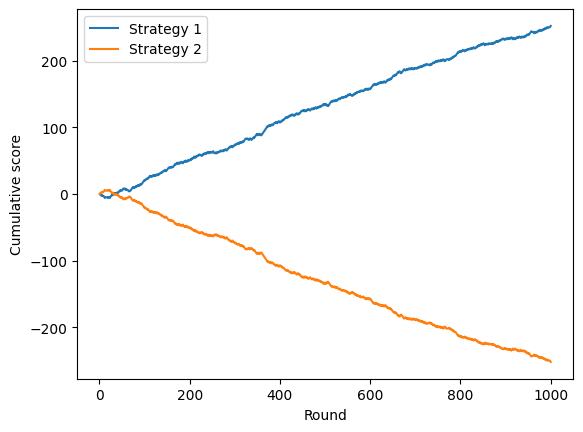

252


In [9]:
# look at detailed game for a single strat
for i in range(1):
    test = PatternBeater(3)
    print(
        simulate_game_verbose(
            1000,
            test.strat_temp_pattern_beater,
            strategies.strat_patternmatcher_1d_v1,
        )[0][0]
    )